In [ ]:
import torch
from torch import nn
import numpy as np
import pandas as pd
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt



##Extracting The Dataset In Google Colab

In [ ]:
#from google.colab import auth
#from google.auth import default
#from googleapiclient.discovery import build
#from googleapiclient.http import MediaIoBaseDownload
#import io
#import os
#import zipfile
#
#
## 1. Authenticate and initialize
#auth.authenticate_user()
#creds, _ = default()
#service = build('drive', 'v3', credentials=creds)
#
#def download_and_extract_zip(folder_id, local_path, target_filename='dataset.zip'):
#    """Finds a specific zip file in the folder, downloads, and extracts it."""
#    os.makedirs(local_path, exist_ok=True)
#
#    # Search for the specific zip file by name in the specified folder
#    query = f"'{folder_id}' in parents and name = '{target_filename}' and mimeType = 'application/x-zip-compressed' and trashed = false"
#    results = service.files().list(q=query, fields="files(id, name)").execute()
#    items = results.get('files', [])
#
#    if not items:
#        print(f"No file named '{target_filename}' found in the specified folder.")
#        return
#
#    # Download the specific zip file found
#    file_id = items[0]['id']
#    file_name = items[0]['name']
#    zip_file_path = os.path.join(local_path, file_name)
#
#    print(f"Downloading {file_name}...")
#    request = service.files().get_media(fileId=file_id)
#
#    with io.FileIO(zip_file_path, 'wb') as fh:
#        downloader = MediaIoBaseDownload(fh, request)
#        done = False
#        while done is False:
#            status, done = downloader.next_chunk()
#            print(f"Download {int(status.progress() * 100)}%.")
#
#    print(f"Extracting {file_name} to {local_path}...")
#    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#        zip_ref.extractall(local_path)
#
#    print("Extraction complete!")
#
## --- EXECUTION ---
#target_folder_id = '1sxJyFLzD3Q7v8XejGoqWHwHl6aZwRsIS'
#base_download_path = './dataset'
#
#download_and_extract_zip(target_folder_id, base_download_path, 'dataset.zip')

Download 12%.
Download 24%.
Download 36%.
Download 48%.
Download 60%.
Download 73%.
Download 85%.
Download 97%.
Download 100%.
Extracting dataset.zip to ./dataset...
Extraction complete!


#Data Visualization

Total images in train: 29229


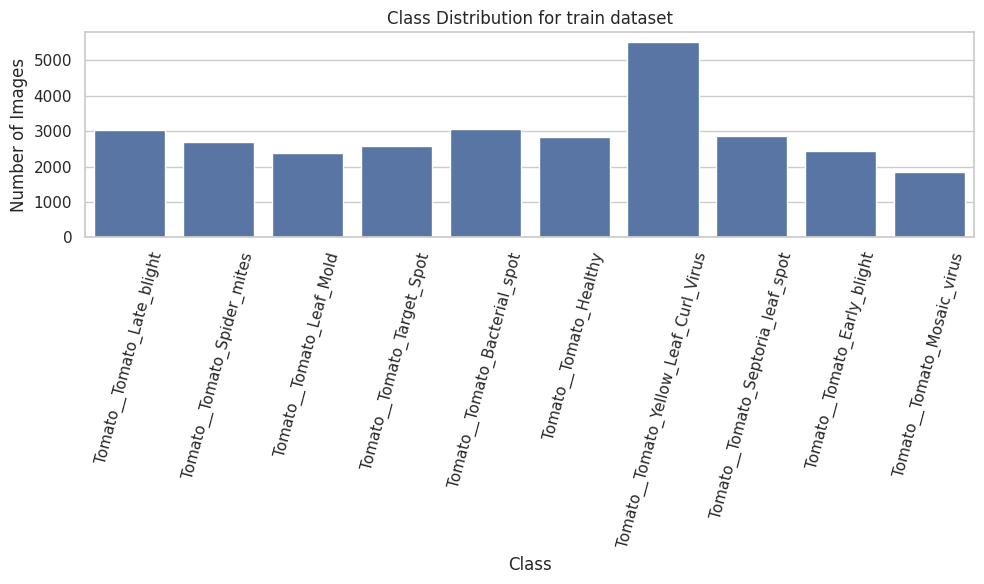

Total images in val: 6260


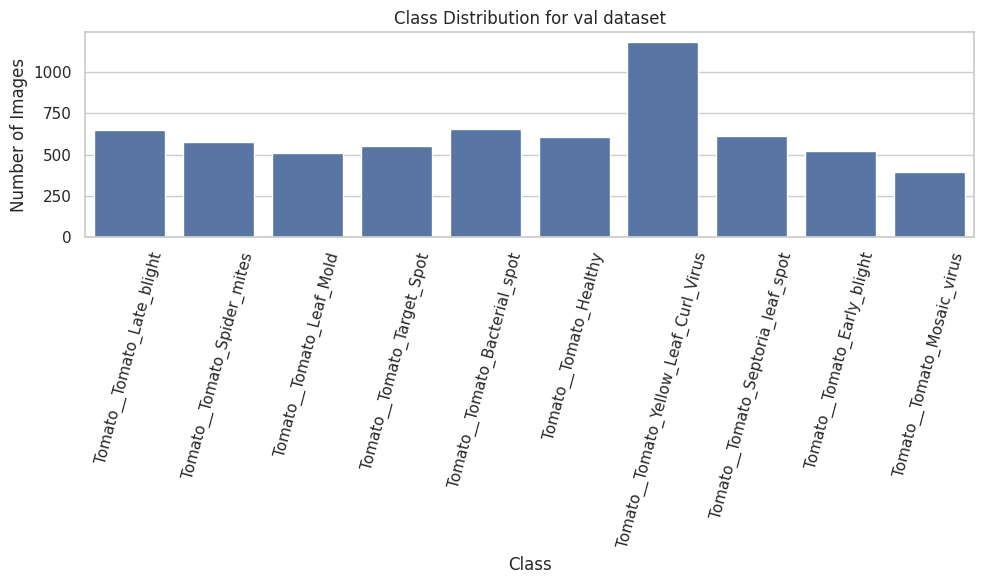

Total images in test: 6274


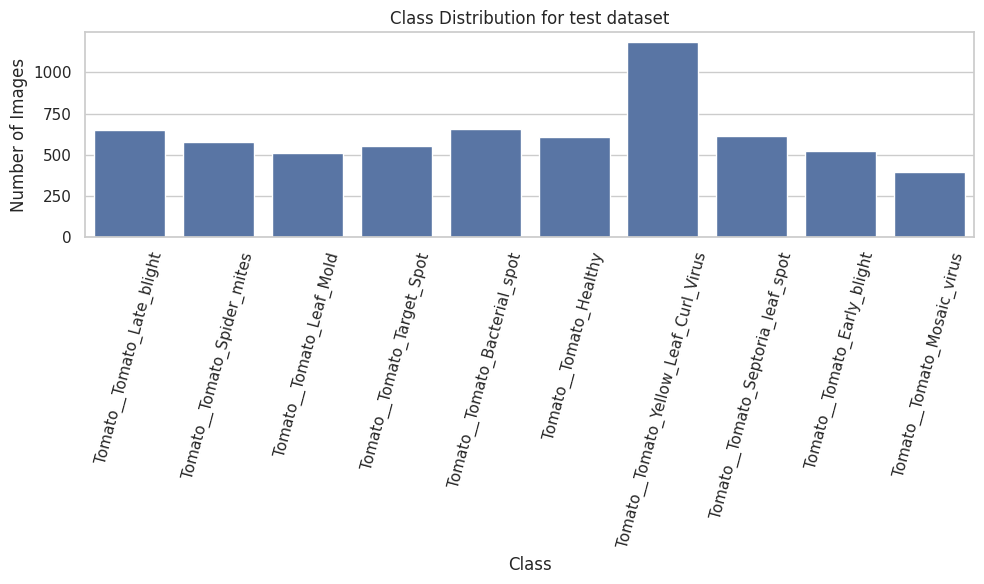


Total images across train + val + test: 41763


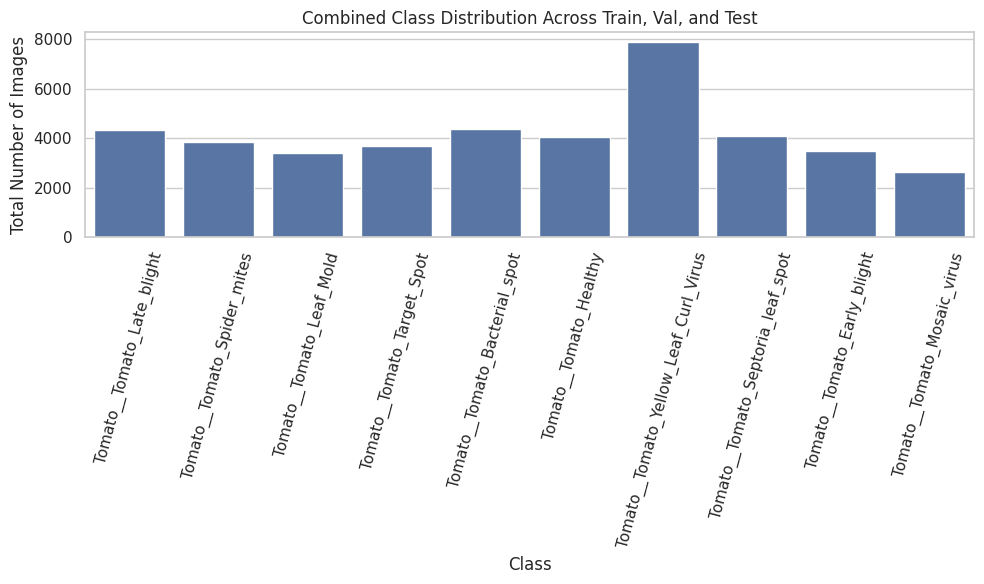

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

base_path = 'dataset/'
splits = ['train', 'val', 'test']

def count_images_in_split(dataset_path):
    class_counts = {}

    for class_name in os.listdir(dataset_path):
        class_folder = os.path.join(dataset_path, class_name)

        if os.path.isdir(class_folder):
            if class_name == 'duplicates':
                continue

            # Count only files, not subfolders
            num_images = len([
                f for f in os.listdir(class_folder)
                if os.path.isfile(os.path.join(class_folder, f))
            ])

            class_counts[class_name] = num_images

    return class_counts

# Store counts for all splits
all_split_counts = {}
total_images_all_splits = 0
combined_class_counts = {}

for split in splits:
    split_path = os.path.join(base_path, split)
    class_counts = count_images_in_split(split_path)
    all_split_counts[split] = class_counts

    # Total images in this split
    split_total = sum(class_counts.values())
    total_images_all_splits += split_total

    print(f"Total images in {split}: {split_total}")

    # Add to combined class counts
    for class_name, count in class_counts.items():
        combined_class_counts[class_name] = combined_class_counts.get(class_name, 0) + count

    # Plot this split
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
    plt.title(f"Class Distribution for {split} dataset")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()

print(f"\nTotal images across train + val + test: {total_images_all_splits}")

plt.figure(figsize=(10, 6))
sns.barplot(x=list(combined_class_counts.keys()), y=list(combined_class_counts.values()))
plt.title("Combined Class Distribution Across Train, Val, and Test")
plt.xlabel("Class")
plt.ylabel("Total Number of Images")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


#Analysing the image sizes and their aspect ratio's across all images

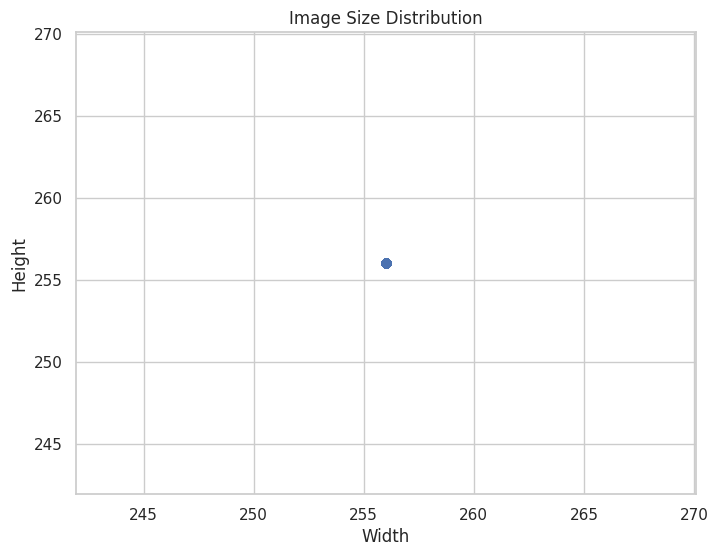

In [ ]:
from PIL import Image
import numpy as np
from collections import Counter
import random

image_shapes = []

for split_name in splits: # Iterate through 'train', 'val', 'test'
    split_folder = os.path.join(base_path, split_name)
    if not os.path.isdir(split_folder):
        continue # Skip if it's not a directory

    for class_name in os.listdir(split_folder): # Iterate through class folders within the split
        class_folder = os.path.join(split_folder, class_name)
        if not os.path.isdir(class_folder):
            continue # Skip if it's not a directory (e.g., .DS_Store or other non-class files)

        # Limit for speed, collect images from this class folder
        for img_name in os.listdir(class_folder)[:100]:
            img_path = os.path.join(class_folder, img_name)
            if os.path.isfile(img_path): # Ensure it's a file before trying to open
                try:
                    img = Image.open(img_path)
                    image_shapes.append(img.size)  # (width, height)
                except Exception as e:
                    print(f"Could not open image {img_path}: {e}")

if image_shapes: # Only proceed if image_shapes is not empty
    widths, heights = zip(*image_shapes)
    plt.figure(figsize=(8,6))
    plt.scatter(widths, heights, alpha=0.5)
    plt.xlabel('Width')
    plt.ylabel('Height')
    plt.title('Image Size Distribution')
    plt.grid(True)
    plt.show()
else:
    print("No images found to process for size distribution.")

#Colour Ditribution


Total images processed: 41763


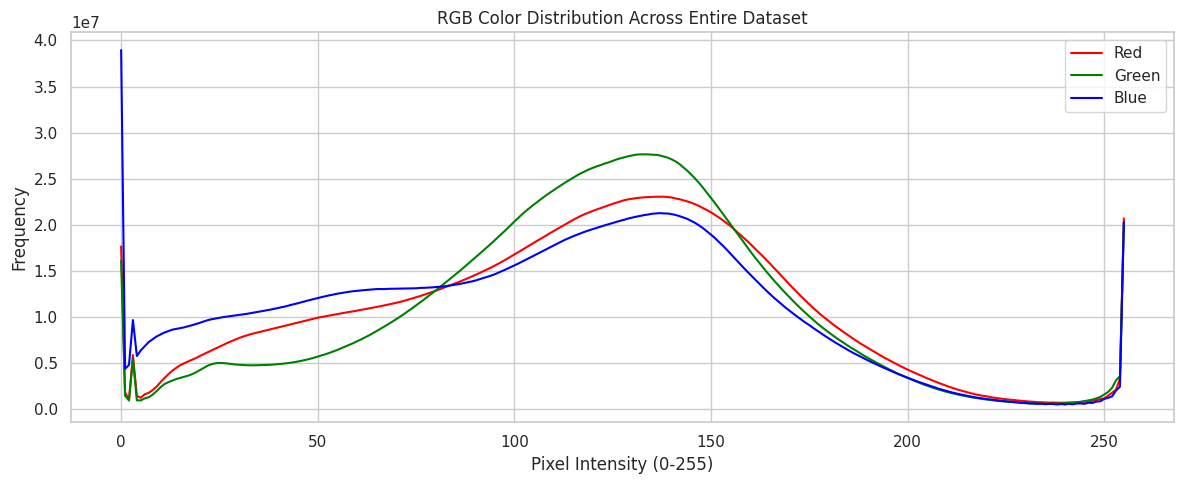

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

base_path = "dataset/"
splits = ["train", "val", "test"]
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

r_hist = np.zeros(256, dtype=np.int64)
g_hist = np.zeros(256, dtype=np.int64)
b_hist = np.zeros(256, dtype=np.int64)

total_images = 0

for split in splits:
    split_path = os.path.join(base_path, split)

    for class_name in os.listdir(split_path):
        class_folder = os.path.join(split_path, class_name)

        if not os.path.isdir(class_folder):
            continue
        if class_name == "duplicates":
            continue

        for file_name in os.listdir(class_folder):
            if not file_name.lower().endswith(image_extensions):
                continue

            img_path = os.path.join(class_folder, file_name)

            try:
                img = Image.open(img_path).convert("RGB")
                img_array = np.array(img)

                # Separate channels
                r = img_array[:, :, 0].flatten()
                g = img_array[:, :, 1].flatten()
                b = img_array[:, :, 2].flatten()

                # Accumulate histogram counts
                r_hist += np.bincount(r, minlength=256)
                g_hist += np.bincount(g, minlength=256)
                b_hist += np.bincount(b, minlength=256)

                total_images += 1

            except Exception as e:
                print(f"Could not read {img_path}: {e}")

print("Total images processed:", total_images)

# Plot combined RGB histogram for entire dataset
plt.figure(figsize=(12, 5))
plt.plot(r_hist, color='red', label='Red')
plt.plot(g_hist, color='green', label='Green')
plt.plot(b_hist, color='blue', label='Blue')
plt.title("RGB Color Distribution Across Entire Dataset")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
from collections import defaultdict
from itertools import combinations
from PIL import Image
import imagehash
import pandas as pd

base_path = "dataset/"
splits = ["train", "val", "test"]
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

def collect_images(base_path, splits):
    image_info = []

    for split in splits:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            continue

        for class_name in os.listdir(split_path):
            class_folder = os.path.join(split_path, class_name)

            if not os.path.isdir(class_folder):
                continue
            if class_name == "duplicates":
                continue

            for file_name in os.listdir(class_folder):
                if file_name.lower().endswith(image_extensions):
                    image_info.append({
                        "split": split,
                        "class_name": class_name,
                        "file_name": file_name,
                        "path": os.path.join(class_folder, file_name)
                    })

    return image_info

def compute_phash_hex(image_path, hash_size=8):
    try:
        img = Image.open(image_path).convert("RGB")
        return str(imagehash.phash(img, hash_size=hash_size))
    except Exception as e:
        print(f"Skipping {image_path}: {e}")
        return None

def build_hash_index(image_info, hash_size=8):
    valid_images = []

    for item in image_info:
        h = compute_phash_hex(item["path"], hash_size=hash_size)
        if h is not None:
            item["phash"] = h
            valid_images.append(item)

    return valid_images

def hamming_hex(hash1, hash2):
    return (int(hash1, 16) ^ int(hash2, 16)).bit_count()

def find_near_duplicates_bucketed(image_info, threshold=5, prefix_len=4, only_across_splits=True):
    buckets = defaultdict(list)

    for item in image_info:
        prefix = item["phash"][:prefix_len]
        buckets[prefix].append(item)

    matches = []

    for bucket_items in buckets.values():
        if len(bucket_items) < 2:
            continue

        for img1, img2 in combinations(bucket_items, 2):
            if only_across_splits and img1["split"] == img2["split"]:
                continue

            dist = hamming_hex(img1["phash"], img2["phash"])
            if dist <= threshold:
                matches.append({
                    "distance": dist,
                    "img1_path": img1["path"],
                    "img2_path": img2["path"],
                    "img1_split": img1["split"],
                    "img2_split": img2["split"],
                    "img1_class": img1["class_name"],
                    "img2_class": img2["class_name"]
                })

    matches.sort(key=lambda x: x["distance"])
    return matches

images = collect_images(base_path, splits)
print("Images found:", len(images))

images = build_hash_index(images, hash_size=8)
print("Images hashed:", len(images))

near_duplicates = find_near_duplicates_bucketed(
    images,
    threshold=5,
    prefix_len=4,
    only_across_splits=True
)

print("Near-duplicate pairs found:", len(near_duplicates))

df_duplicates = pd.DataFrame(near_duplicates)
df_duplicates.head(20)

Images found: 41763
Images hashed: 41763
Near-duplicate pairs found: 7291


,distance,img1_path,img2_path,img1_split,img2_split,img1_class,img2_class
0,0,/content/dataset/train/Tomato__Tomato_Bacteria...,/content/dataset/test/Tomato__Tomato_Bacterial...,train,test,Tomato__Tomato_Bacterial_spot,Tomato__Tomato_Bacterial_spot
1,0,/content/dataset/val/Tomato__Tomato_Mosaic_vir...,/content/dataset/test/Tomato__Tomato_Mosaic_vi...,val,test,Tomato__Tomato_Mosaic_virus,Tomato__Tomato_Mosaic_virus
2,0,/content/dataset/train/Tomato__Tomato_Late_bli...,/content/dataset/val/Tomato__Tomato_Late_bligh...,train,val,Tomato__Tomato_Late_blight,Tomato__Tomato_Late_blight
3,0,/content/dataset/train/Tomato__Tomato_Spider_m...,/content/dataset/val/Tomato__Tomato_Spider_mit...,train,val,Tomato__Tomato_Spider_mites,Tomato__Tomato_Spider_mites
4,0,/content/dataset/train/Tomato__Tomato_Septoria...,/content/dataset/val/Tomato__Tomato_Septoria_l...,train,val,Tomato__Tomato_Septoria_leaf_spot,Tomato__Tomato_Septoria_leaf_spot
5,0,/content/dataset/train/Tomato__Tomato_Early_bl...,/content/dataset/test/Tomato__Tomato_Early_bli...,train,test,Tomato__Tomato_Early_blight,Tomato__Tomato_Early_blight
6,0,/content/dataset/train/Tomato__Tomato_Late_bli...,/content/dataset/test/Tomato__Tomato_Late_blig...,train,test,Tomato__Tomato_Late_blight,Tomato__Tomato_Late_blight
7,0,/content/dataset/val/Tomato__Tomato_Late_bligh...,/content/dataset/test/Tomato__Tomato_Late_blig...,val,test,Tomato__Tomato_Late_blight,Tomato__Tomato_Late_blight
8,0,/content/dataset/train/Tomato__Tomato_Leaf_Mol...,/content/dataset/test/Tomato__Tomato_Leaf_Mold...,train,test,Tomato__Tomato_Leaf_Mold,Tomato__Tomato_Leaf_Mold
9,0,/content/dataset/train/Tomato__Tomato_Leaf_Mol...,/content/dataset/test/Tomato__Tomato_Leaf_Mold...,train,test,Tomato__Tomato_Leaf_Mold,Tomato__Tomato_Leaf_Mold


# Model Creation & Training


## Defining the Dataset and Image to Tensor Conversion

In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix

BASE_PATH   = "dataset/"
IMG_SIZE    = 128
FLAT_DIM    = IMG_SIZE * IMG_SIZE * 3
BATCH_SIZE  = 64
NUM_WORKERS = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class TomatoDataset(Dataset):
  VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
  def __init__(self, base_path: str, split: str, transform=None):
    self.transform = transform
    self.samples: list[tuple[str, int]] = []
    split_dir = os.path.join(base_path, split)
    class_names = sorted(
      d for d in os.listdir(split_dir)
      if os.path.isdir(os.path.join(split_dir, d)) and d != 'duplicates'
    )

    self.class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    self.idx_to_class = {idx: name for name, idx in self.class_to_idx.items()}
    self.classes      = class_names

    for class_name in class_names:
      class_dir = os.path.join(split_dir, class_name)
      label     = self.class_to_idx[class_name]
      for fname in os.listdir(class_dir):
        if os.path.splitext(fname)[1].lower() in self.VALID_EXT:
          self.samples.append((os.path.join(class_dir, fname), label))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, label = self.samples[idx]
    image = Image.open(img_path).convert('RGB')
    if self.transform:
      image = self.transform(image)
    return image, label


def load_data(base_path=BASE_PATH, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
  train_ds = TomatoDataset(base_path, 'train', transform=train_transform)
  val_ds   = TomatoDataset(base_path, 'val',   transform=eval_transform)
  test_ds  = TomatoDataset(base_path, 'test',  transform=eval_transform)
  class_names = train_ds.classes
  kw = dict(batch_size=batch_size, num_workers=num_workers, pin_memory=True)
  train_loader = DataLoader(train_ds, shuffle=True,  **kw)
  val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
  test_loader  = DataLoader(test_ds,  shuffle=False, **kw)
  print(f"Classes ({len(class_names)}): {class_names}")
  print(f"Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}")
  return train_loader, val_loader, test_loader, class_names

## Defining The MLP Model

In [ ]:
class TomatoMLP(nn.Module):
  def __init__(self, input_dim=FLAT_DIM, hidden_dims=None,
             num_classes=10, dropout_rate=0.4):
    super().__init__()
    if hidden_dims is None:
        hidden_dims = [2048, 1024, 512, 256]
    layers = [nn.BatchNorm1d(input_dim)]
    prev   = input_dim
    for h in hidden_dims:
        layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                   nn.ReLU(inplace=True), nn.Dropout(dropout_rate)]
        prev = h
    layers.append(nn.Linear(prev, num_classes))
    self.net = nn.Sequential(*layers)

  def forward(self, x):
      return self.net(x.view(x.size(0), -1))

## Defining the ResNet Model

In [ ]:
from torchvision import models

class TomatoResNet(nn.Module):
  def __init__(self, num_classes: int, dropout_rate: float = 0.3,
             fine_tune_all: bool = False):
    super().__init__()
    backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    if not fine_tune_all:
        for param in backbone.parameters():
            param.requires_grad = False
    in_features = backbone.fc.in_features
    backbone.fc = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(in_features, num_classes)
    )
    self.net = backbone
  def forward(self, x):
      return self.net(x)

## Defining the DenseNet Model

In [ ]:
def conv_block(in_channels, growth_rate):
    return nn.Sequential(
        nn.BatchNorm2d(in_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False),
    )


class DenseBlock(nn.Module):
    def __init__(self, num_convs, in_channels, growth_rate):
        super().__init__()
        self.layers = nn.ModuleList()
        current_channels = in_channels
        for _ in range(num_convs):
            self.layers.append(conv_block(current_channels, growth_rate))
            current_channels += growth_rate
        self.out_channels = current_channels
    def forward(self, x):
        for layer in self.layers:
            y = layer(x)
            x = torch.cat([x, y], dim=1)
        return x


class TransitionBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )

    def forward(self, x):
        return self.block(x)


class TomatoDenseNet(nn.Module):
    def __init__(self, num_classes, init_channels=64, growth_rate=32,
                 block_config=(4, 4, 4, 4)):
        super().__init__()


        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        channels = init_channels
        features = []
        for i, num_convs in enumerate(block_config):
            db = DenseBlock(num_convs=num_convs,
                            in_channels=channels,
                            growth_rate=growth_rate)
            features.append(db)
            channels = db.out_channels
            if i != len(block_config) - 1:
                out_channels = channels // 2
                features.append(TransitionBlock(channels, out_channels))
                channels = out_channels

        self.features = nn.Sequential(*features)

        self.final_bn   = nn.BatchNorm2d(channels)
        self.final_relu = nn.ReLU(inplace=True)
        self.pool       = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.final_bn(x)
        x = self.final_relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

## Defining Custom Trainer

In [ ]:
class Trainer:
  def __init__(self, model, train_loader, val_loader, device, lr=1e-3, weight_decay=1e-4):
    self.model        = model.to(device)
    self.train_loader = train_loader
    self.val_loader   = val_loader
    self.device       = device
    self.criterion    = nn.CrossEntropyLoss()
    self.optimizer    = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    self.scheduler    = optim.lr_scheduler.CosineAnnealingWarmRestarts(self.optimizer, T_0=10,
                                                                       T_mult=2)
    self.history      = {"model": model.__class__.__name__,"train_loss": [], "val_loss": [], "train_acc":  [], "val_acc":  []}
    self.best_val_acc = 0.0

  def _run_epoch(self, loader, train: bool):
    self.model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
      for images, labels in tqdm(loader, desc="train" if train else "val  ", leave=False):
        images = images.to(self.device)
        labels = labels.to(self.device)
        outputs = self.model(images)
        loss    = self.criterion(outputs, labels)
        if train:
         self.optimizer.zero_grad()
         loss.backward()
         nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
         self.optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

  def fit(self, epochs: int, checkpoint_dir: str = "checkpoints"):
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(1, epochs + 1):
      t0 = time.time()
      train_loss, train_acc = self._run_epoch(self.train_loader, train=True)
      val_loss,   val_acc   = self._run_epoch(self.val_loader,   train=False)
      self.scheduler.step()
      self.history["train_loss"].append(train_loss)
      self.history["val_loss"].append(val_loss)
      self.history["train_acc"].append(train_acc)
      self.history["val_acc"].append(val_acc)
      print(f"Epoch {epoch:3d}/{epochs} | "
            f"loss {train_loss:.4f}/{val_loss:.4f} | "
            f"acc  {train_acc:.4f}/{val_acc:.4f} | "
            f"{time.time()-t0:.1f}s")
      if val_acc > self.best_val_acc:
        self.best_val_acc = val_acc
        path = os.path.join(checkpoint_dir, str(self.model.__class__.__name__+"_best_model.pt"))
        torch.save({"epoch": epoch, "state_dict": self.model.state_dict(),
                    "val_acc": val_acc, "optimizer": self.optimizer.state_dict()}, path)
        print(f"  ✓ Best model saved  (val_acc={val_acc:.4f})")
    return self.history

##Defining Evaluation Functions

In [ ]:
def evaluate(model, test_loader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="test "):
            preds = model(images.to(device)).argmax(1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    print("\n── Classification Report ──────────────────────────────")
    print(classification_report(all_labels, all_preds,
                                 target_names=class_names, digits=4))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(model.__class__.__name__+" — Confusion Matrix")
    plt.tight_layout()
    plt.savefig(model.__class__.__name__+"_confusion_matrix.png", dpi=150)
    plt.show()



def plot_history(history: dict):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
    ax1.plot(epochs, history["val_loss"],   label="Val Loss",   color="tomato")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title("Loss Curves"); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["train_acc"], label="Train Acc", color="steelblue")
    ax2.plot(epochs, history["val_acc"],   label="Val Acc",   color="tomato")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_title("Accuracy Curves"); ax2.legend(); ax2.grid(True, alpha=0.3)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    plt.tight_layout()
    plt.savefig(str(history["model"])+"_training_curves.png", dpi=150)
    plt.show()
    print("Saved → "+history["model"]+"_training_curves.png")


## Initializing Training Variables

In [ ]:
EPOCHS      = 15
LR          = 1e-3
DROPOUT     = 0.4
HIDDEN_DIMS = [2048, 1024, 512, 256]


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

train_loader, val_loader, test_loader, class_names = load_data()
num_classes = len(class_names)

Device: cuda
Classes (10): ['Tomato__Tomato_Bacterial_spot', 'Tomato__Tomato_Early_blight', 'Tomato__Tomato_Healthy', 'Tomato__Tomato_Late_blight', 'Tomato__Tomato_Leaf_Mold', 'Tomato__Tomato_Mosaic_virus', 'Tomato__Tomato_Septoria_leaf_spot', 'Tomato__Tomato_Spider_mites', 'Tomato__Tomato_Target_Spot', 'Tomato__Tomato_Yellow_Leaf_Curl_Virus']
Train: 29,229  |  Val: 6,260  |  Test: 6,274


## Training and Evaluating MLP Model

In [ ]:
mlpModel = TomatoMLP(input_dim=FLAT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=num_classes, dropout_rate=DROPOUT)
trainer = Trainer(mlpModel, train_loader, val_loader, device, lr=LR)
history = trainer.fit(EPOCHS)

Epoch   1/15 | loss 1.4315/0.9581 | acc  0.5021/0.6540 | 117.0s
  ✓ Best model saved  (val_acc=0.6540)


Epoch   2/15 | loss 1.0617/0.7977 | acc  0.6320/0.7179 | 114.2s
  ✓ Best model saved  (val_acc=0.7179)


Epoch   3/15 | loss 0.9568/0.6493 | acc  0.6680/0.7728 | 114.2s
  ✓ Best model saved  (val_acc=0.7728)


Epoch   4/15 | loss 0.8806/0.5774 | acc  0.6952/0.8000 | 113.5s
  ✓ Best model saved  (val_acc=0.8000)


Epoch   5/15 | loss 0.8174/0.5564 | acc  0.7174/0.8064 | 115.4s
  ✓ Best model saved  (val_acc=0.8064)


...

Epoch  11/15 | loss 0.7614/0.5539 | acc  0.7347/0.8042 | 113.1s


Epoch  12/15 | loss 0.7507/0.4784 | acc  0.7385/0.8369 | 114.1s


Epoch  13/15 | loss 0.7297/0.4561 | acc  0.7469/0.8436 | 114.6s


Epoch  14/15 | loss 0.6974/0.4465 | acc  0.7586/0.8492 | 114.1s


Epoch  15/15 | loss 0.6749/0.4112 | acc  0.7637/0.8607 | 112.8s


test : 100%|██████████| 99/99 [00:12<00:00,  7.97it/s]



── Classification Report ──────────────────────────────
                                       precision    recall  f1-score   support

        Tomato__Tomato_Bacterial_spot     0.8824    0.7798    0.8279       654
          Tomato__Tomato_Early_blight     0.7778    0.6826    0.7271       523
               Tomato__Tomato_Healthy     0.9386    0.9031    0.9205       609
           Tomato__Tomato_Late_blight     0.8495    0.7304    0.7854       649
             Tomato__Tomato_Leaf_Mold     0.8386    0.8782    0.8580       509
          Tomato__Tomato_Mosaic_virus     0.8902    0.9549    0.9214       399
    Tomato__Tomato_Septoria_leaf_spot     0.8362    0.8553    0.8457       615
          Tomato__Tomato_Spider_mites     0.8193    0.9240    0.8685       579
           Tomato__Tomato_Target_Spot     0.8049    0.8339    0.8191       554
Tomato__Tomato_Yellow_Leaf_Curl_Virus     0.8871    0.9569    0.9207      1183

                             accuracy                         0.8566    

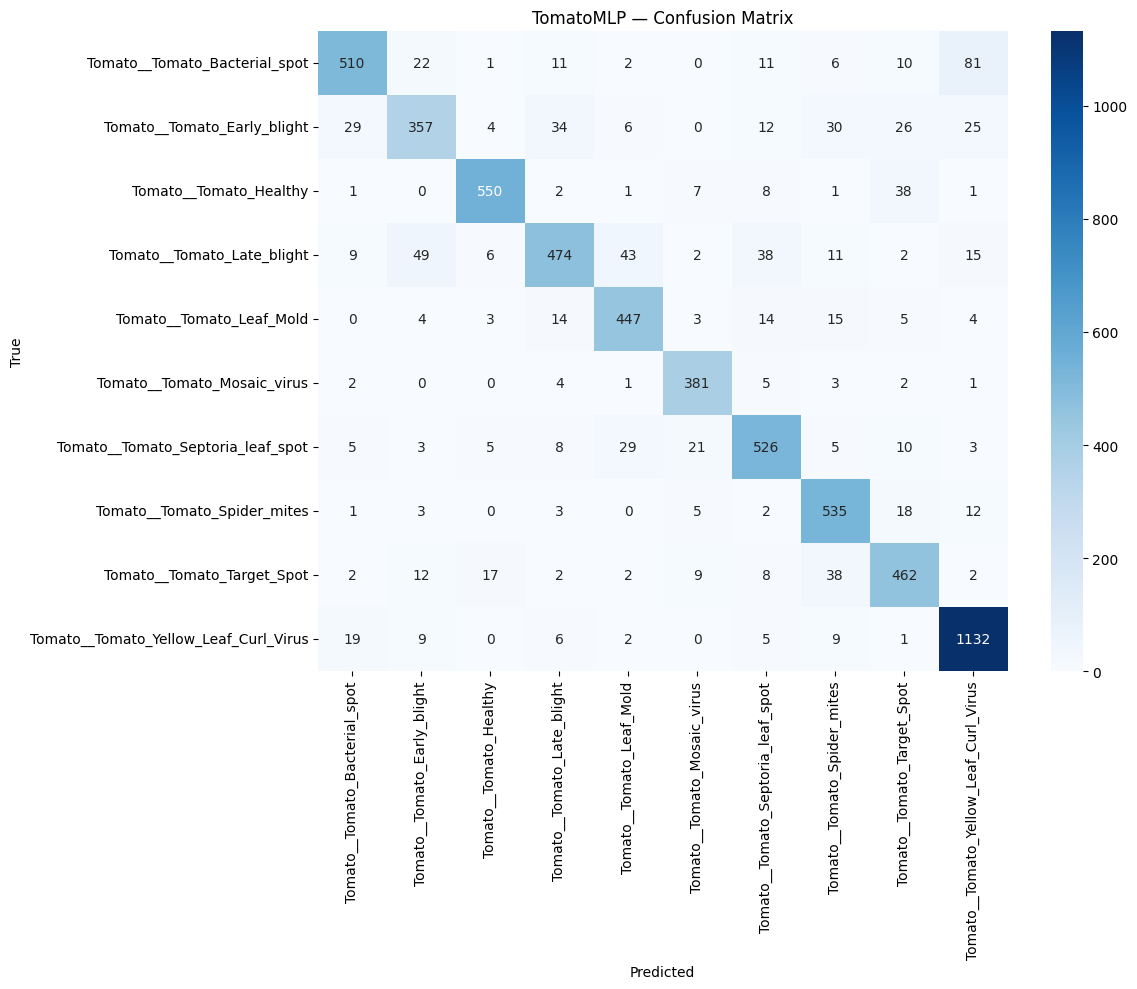

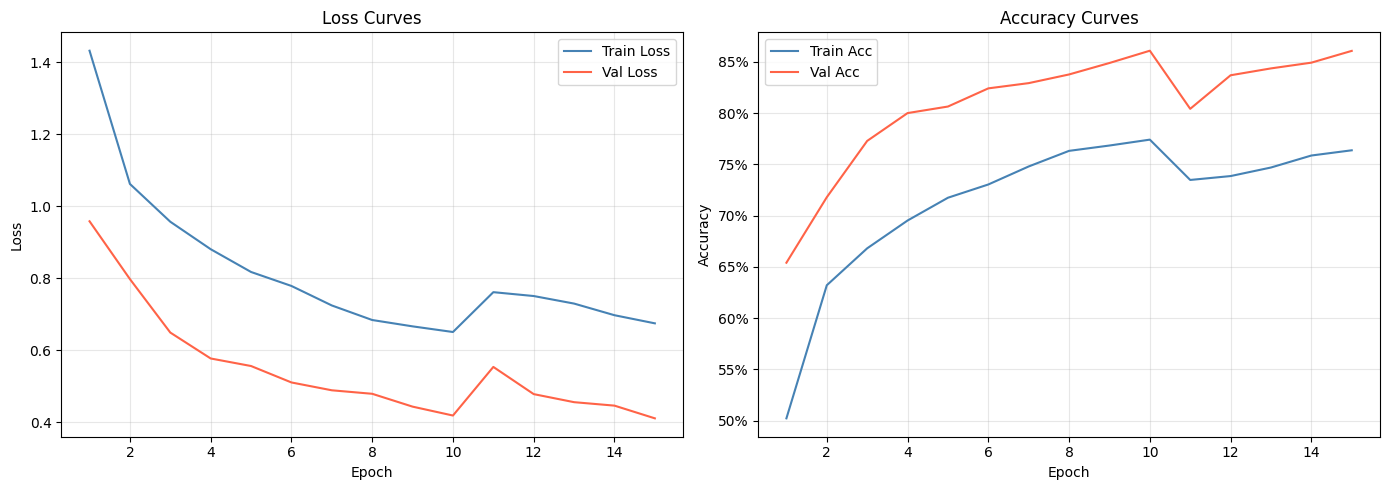

Saved → TomatoMLP_training_curves.png


In [ ]:
best_ckpt = torch.load(str("checkpoints/"+mlpModel.__class__.__name__+"_best_model.pt"), map_location=device)
mlpModel.load_state_dict(best_ckpt["state_dict"])
mlpModel.to(device)
evaluate(mlpModel, test_loader, class_names, device)
plot_history(history)

## Training and Evaluating the ResNet Model

In [ ]:
resNetModel= TomatoResNet(num_classes=num_classes, dropout_rate=DROPOUT)
trainer = Trainer(resNetModel, train_loader, val_loader, device, lr=LR)
history = trainer.fit(EPOCHS)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


Epoch   1/15 | loss 1.1093/0.7191 | acc  0.6773/0.8099 | 116.7s
  ✓ Best model saved  (val_acc=0.8099)


Epoch   2/15 | loss 0.7248/0.5706 | acc  0.7779/0.8439 | 116.1s
  ✓ Best model saved  (val_acc=0.8439)


Epoch   3/15 | loss 0.6595/0.5176 | acc  0.7909/0.8634 | 115.9s
  ✓ Best model saved  (val_acc=0.8634)


...

Epoch  11/15 | loss 0.5803/0.4160 | acc  0.8108/0.8746 | 116.0s


Epoch  12/15 | loss 0.5834/0.4113 | acc  0.8102/0.8804 | 114.4s


Epoch  13/15 | loss 0.5865/0.3887 | acc  0.8062/0.8810 | 115.1s


Epoch  14/15 | loss 0.5741/0.3897 | acc  0.8089/0.8859 | 115.0s
  ✓ Best model saved  (val_acc=0.8859)


Epoch  15/15 | loss 0.5649/0.3932 | acc  0.8146/0.8863 | 116.8s
  ✓ Best model saved  (val_acc=0.8863)


test : 100%|██████████| 99/99 [00:12<00:00,  8.25it/s]



── Classification Report ──────────────────────────────
                                       precision    recall  f1-score   support

        Tomato__Tomato_Bacterial_spot     0.9304    0.8379    0.8817       654
          Tomato__Tomato_Early_blight     0.8294    0.7438    0.7843       523
               Tomato__Tomato_Healthy     0.8847    0.9704    0.9256       609
           Tomato__Tomato_Late_blight     0.8129    0.8767    0.8436       649
             Tomato__Tomato_Leaf_Mold     0.9219    0.8585    0.8891       509
          Tomato__Tomato_Mosaic_virus     0.9398    0.9398    0.9398       399
    Tomato__Tomato_Septoria_leaf_spot     0.8690    0.8309    0.8495       615
          Tomato__Tomato_Spider_mites     0.8433    0.9292    0.8841       579
           Tomato__Tomato_Target_Spot     0.8963    0.7491    0.8161       554
Tomato__Tomato_Yellow_Leaf_Curl_Virus     0.9067    0.9856    0.9445      1183

                             accuracy                         0.8828    

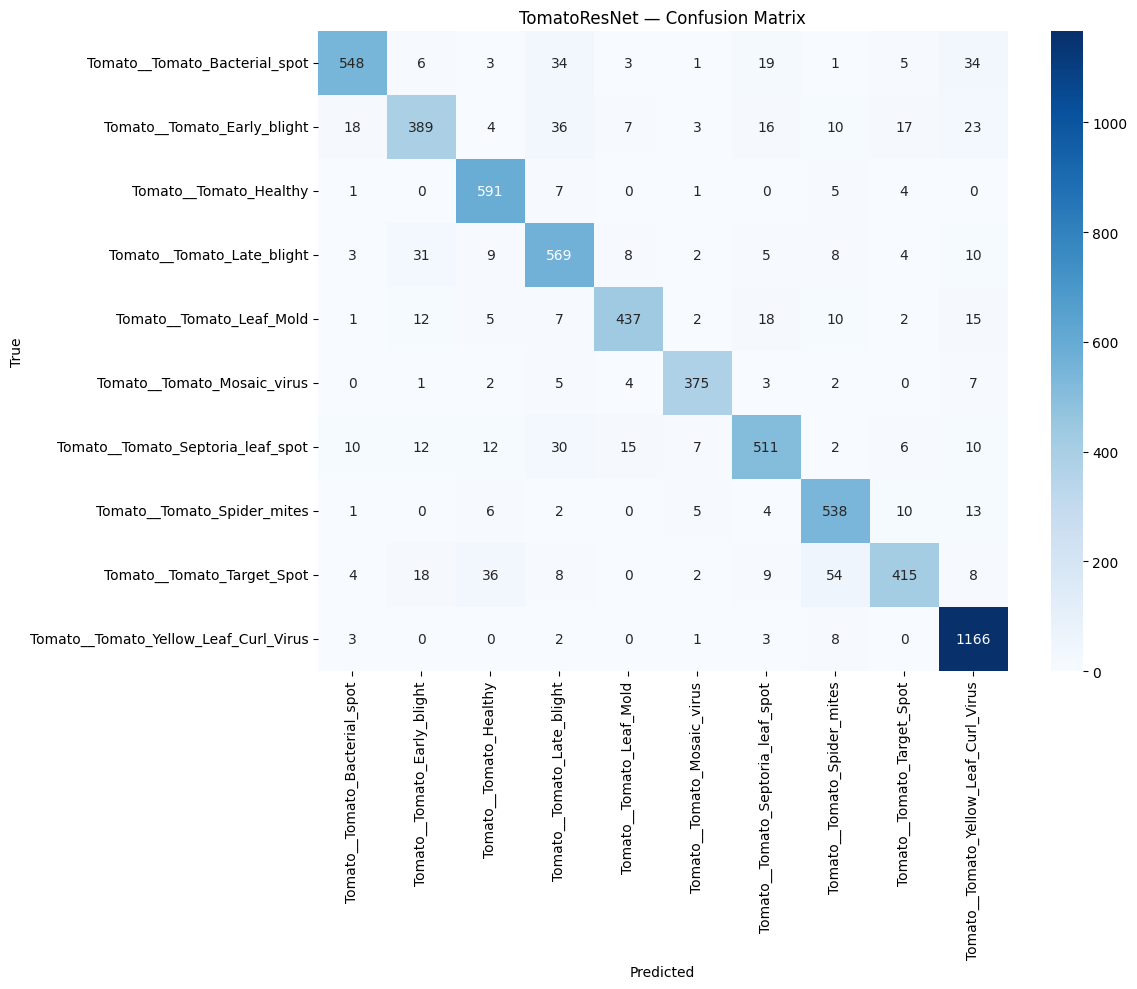

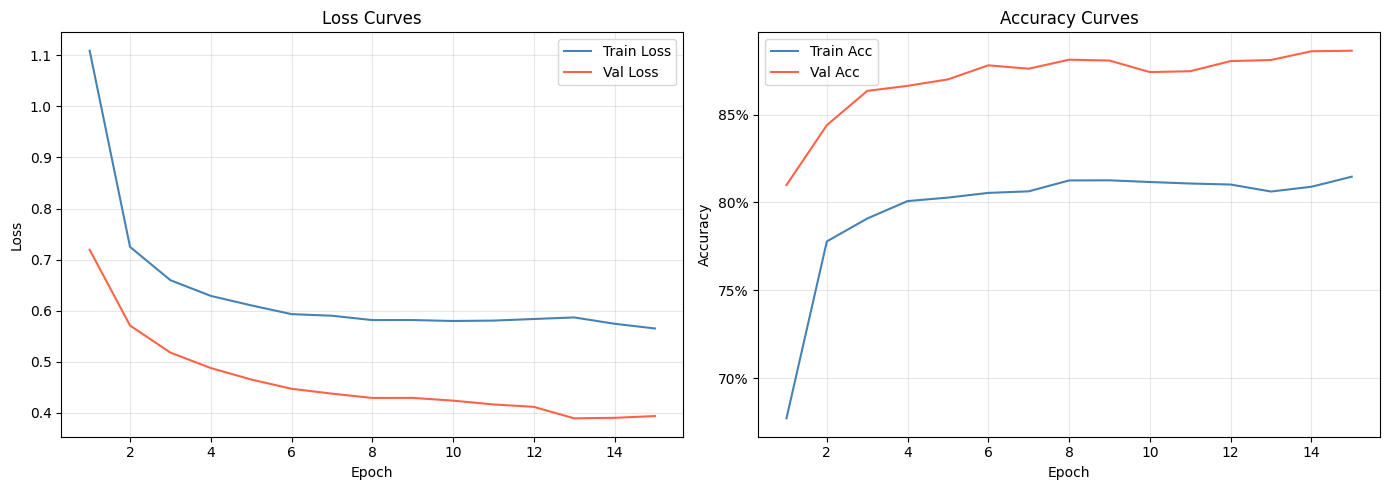

Saved → TomatoResNet_training_curves.png


In [ ]:
best_ckpt= torch.load(str("checkpoints/"+resNetModel.__class__.__name__+"_best_model.pt"), map_location=device)
resNetModel.load_state_dict(best_ckpt["state_dict"])
resNetModel.to(device)
evaluate(resNetModel, test_loader, class_names, device)
plot_history(history)

## Training and Evaluating the DenseNet Model

In [ ]:
denseNetModel = TomatoDenseNet(
    num_classes=num_classes,
    init_channels=64,
    growth_rate=32,
    block_config=(4, 4, 4, 4)
)
trainer = Trainer(denseNetModel, train_loader, val_loader, device, lr=LR)
history = trainer.fit(EPOCHS)



Epoch   1/15 | loss 0.9492/0.4941 | acc  0.6720/0.8308 | 114.4s
  ✓ Best model saved  (val_acc=0.8308)


Epoch   2/15 | loss 0.5582/0.4298 | acc  0.8068/0.8551 | 114.5s
  ✓ Best model saved  (val_acc=0.8551)


Epoch   3/15 | loss 0.4058/0.2485 | acc  0.8607/0.9171 | 115.0s
  ✓ Best model saved  (val_acc=0.9171)


Epoch   4/15 | loss 0.3066/0.2040 | acc  0.8936/0.9331 | 116.4s
  ✓ Best model saved  (val_acc=0.9331)


Epoch   5/15 | loss 0.2503/0.3298 | acc  0.9153/0.8812 | 116.2s


...

Epoch  11/15 | loss 0.2515/0.2038 | acc  0.9140/0.9321 | 114.1s


Epoch  12/15 | loss 0.2199/0.2762 | acc  0.9239/0.9083 | 116.1s


Epoch  13/15 | loss 0.2024/0.1269 | acc  0.9298/0.9569 | 115.5s


Epoch  14/15 | loss 0.1831/0.2065 | acc  0.9373/0.9272 | 117.1s


Epoch  15/15 | loss 0.1596/0.1055 | acc  0.9456/0.9617 | 116.7s


test : 100%|██████████| 99/99 [00:10<00:00,  9.15it/s]



── Classification Report ──────────────────────────────
                                       precision    recall  f1-score   support

        Tomato__Tomato_Bacterial_spot     0.9814    0.9679    0.9746       654
          Tomato__Tomato_Early_blight     0.9768    0.9675    0.9721       523
               Tomato__Tomato_Healthy     0.9868    0.9819    0.9844       609
           Tomato__Tomato_Late_blight     0.9560    0.9707    0.9633       649
             Tomato__Tomato_Leaf_Mold     0.9802    0.9705    0.9753       509
          Tomato__Tomato_Mosaic_virus     0.9975    0.9825    0.9899       399
    Tomato__Tomato_Septoria_leaf_spot     0.9508    0.9740    0.9622       615
          Tomato__Tomato_Spider_mites     0.9879    0.9862    0.9870       579
           Tomato__Tomato_Target_Spot     0.9785    0.9838    0.9811       554
Tomato__Tomato_Yellow_Leaf_Curl_Virus     0.9907    0.9915    0.9911      1183

                             accuracy                         0.9788    

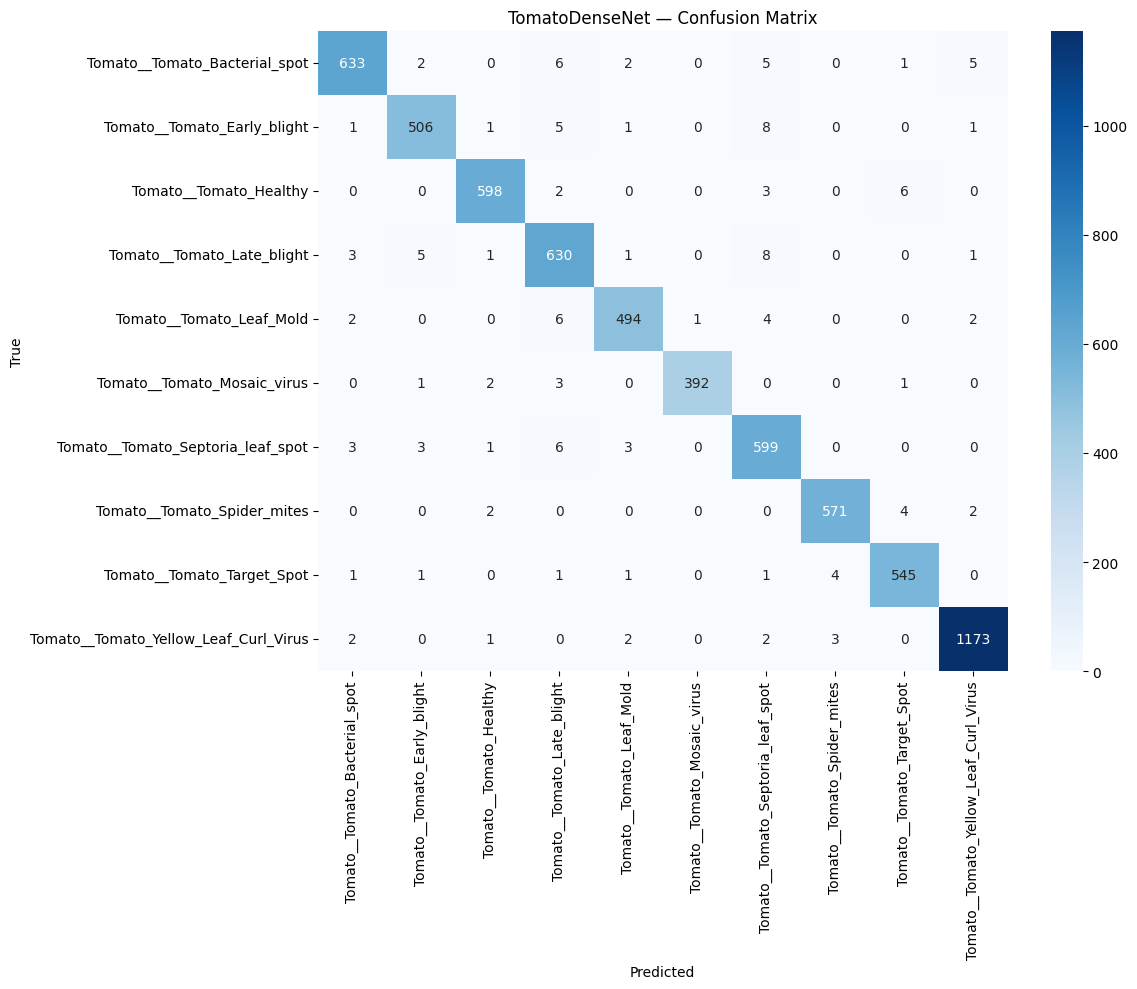

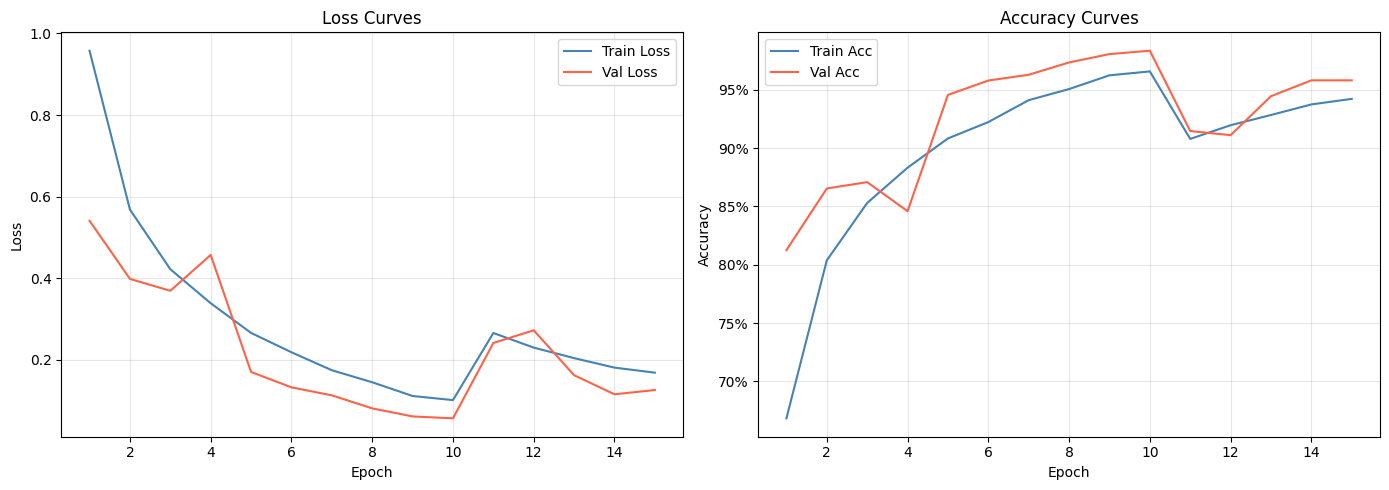

Saved → TomatoDenseNet_training_curves.png


In [ ]:
best_ckpt = torch.load(
    str("checkpoints/" + denseNetModel.__class__.__name__ + "_best_model.pt"),
    map_location=device
)
denseNetModel.load_state_dict(best_ckpt["state_dict"])
denseNetModel.to(device)
evaluate(denseNetModel, test_loader, class_names, device)
plot_history(history)

In [ ]:
import os
from datetime import datetime

SAVE_DIR = "saved_model_bundles"
os.makedirs(SAVE_DIR, exist_ok=True)

def make_model_bundle(model, model_type: str, arch_kwargs: dict):
    return {
        "model_name": model.__class__.__name__,
        "model_type": model_type,
        "state_dict": model.state_dict(),
        "num_classes": len(class_names),
        "class_names": list(class_names),
        "image_size": IMG_SIZE,
        "mean": list(IMAGENET_MEAN),
        "std": list(IMAGENET_STD),
        "arch_kwargs": arch_kwargs,
        "saved_at": datetime.now().isoformat(timespec="seconds"),
    }

print(f"Model bundle directory ready: {os.path.abspath(SAVE_DIR)}")

Model bundle directory ready: /content/saved_model_bundles


In [ ]:
mlp_bundle = make_model_bundle(
    model=mlpModel,
    model_type="mlp",
    arch_kwargs={
        "input_dim": FLAT_DIM,
        "hidden_dims": HIDDEN_DIMS,
        "dropout_rate": DROPOUT,
    },
)

mlp_bundle_path = os.path.join(SAVE_DIR, "TomatoMLP_bundle.pt")
torch.save(mlp_bundle, mlp_bundle_path)
print(f"Saved MLP bundle → {mlp_bundle_path}")

Saved MLP bundle → saved_model_bundles/TomatoMLP_bundle.pt


In [ ]:
resnet_bundle = make_model_bundle(
    model=resNetModel,
    model_type="resnet",
    arch_kwargs={
        "dropout_rate": DROPOUT,
        "fine_tune_all": False,
    },
)

resnet_bundle_path = os.path.join(SAVE_DIR, "TomatoResNet_bundle.pt")
torch.save(resnet_bundle, resnet_bundle_path)
print(f"Saved ResNet bundle → {resnet_bundle_path}")

Saved ResNet bundle → saved_model_bundles/TomatoResNet_bundle.pt


In [ ]:
densenet_bundle = make_model_bundle(
    model=denseNetModel,
    model_type="densenet",
    arch_kwargs={
        "init_channels": 64,
        "growth_rate": 32,
        "block_config": (4, 4, 4, 4),
    },
)

densenet_bundle_path = os.path.join(SAVE_DIR, "TomatoDenseNet_bundle.pt")
torch.save(densenet_bundle, densenet_bundle_path)
print(f"Saved DenseNet bundle → {densenet_bundle_path}")

Saved DenseNet bundle → saved_model_bundles/TomatoDenseNet_bundle.pt


In [ ]:
%pip -q install gradio

In [ ]:
import gradio as gr
from PIL import Image
from torchvision import models, transforms

class DeployTomatoResNet(nn.Module):
    def __init__(self, num_classes: int, dropout_rate: float = 0.3):
        super().__init__()
        backbone = models.resnet50(weights=None)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )
        self.net = backbone

    def forward(self, x):
        return self.net(x)


def build_model_from_bundle(bundle):
    model_type = bundle["model_type"]
    num_classes = bundle["num_classes"]
    arch = bundle.get("arch_kwargs", {})

    if model_type == "mlp":
        model = TomatoMLP(
            input_dim=arch.get("input_dim", FLAT_DIM),
            hidden_dims=arch.get("hidden_dims", [2048, 1024, 512, 256]),
            num_classes=num_classes,
            dropout_rate=arch.get("dropout_rate", 0.4),
        )

    elif model_type == "resnet":
        model = DeployTomatoResNet(
            num_classes=num_classes,
            dropout_rate=arch.get("dropout_rate", 0.4),
        )

    elif model_type == "densenet":
        model = TomatoDenseNet(
            num_classes=num_classes,
            init_channels=arch.get("init_channels", 64),
            growth_rate=arch.get("growth_rate", 32),
            block_config=tuple(arch.get("block_config", (4, 4, 4, 4))),
        )

    else:
        raise ValueError(f"Unknown model type: {model_type}")

    model.load_state_dict(bundle["state_dict"])
    model.to(device)
    model.eval()
    return model


MODEL_BUNDLE_PATHS = {
    "MLP": os.path.join(SAVE_DIR, "TomatoMLP_bundle.pt"),
    "ResNet": os.path.join(SAVE_DIR, "TomatoResNet_bundle.pt"),
    "DenseNet": os.path.join(SAVE_DIR, "TomatoDenseNet_bundle.pt"),
}

loaded_model_cache = {}

def get_model_and_bundle(model_choice: str):
    if model_choice in loaded_model_cache:
        return loaded_model_cache[model_choice]

    bundle_path = MODEL_BUNDLE_PATHS[model_choice]
    if not os.path.exists(bundle_path):
        raise FileNotFoundError(
            f"Bundle not found for {model_choice}. Run that model's save cell first."
        )

    bundle = torch.load(bundle_path, map_location=device)
    model = build_model_from_bundle(bundle)
    loaded_model_cache[model_choice] = (model, bundle)
    return model, bundle


def make_inference_transform(bundle):
    return transforms.Compose([
        transforms.Resize((bundle["image_size"], bundle["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize(mean=bundle["mean"], std=bundle["std"]),
    ])


def predict_leaf(image, model_choice, true_label, stats):
    if image is None:
        raise gr.Error("Please upload a tomato leaf image first.")

    model, bundle = get_model_and_bundle(model_choice)
    transform = make_inference_transform(bundle)
    class_names_local = bundle["class_names"]

    image = image.convert("RGB")
    x = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_class = class_names_local[pred_idx]
    pred_conf = float(probs[pred_idx])

    label_scores = {class_names_local[i]: float(probs[i]) for i in range(len(class_names_local))}

    if stats is None:
        stats = {"correct": 0, "total": 0}

    if true_label != "Skip":
        is_correct = pred_class == true_label
        stats["total"] += 1
        stats["correct"] += int(is_correct)

        verdict = "✅ Correct" if is_correct else "❌ Incorrect"
        result_md = (
            f"### Prediction Result\n"
            f"- **Model:** {model_choice}\n"
            f"- **Predicted class:** `{pred_class}`\n"
            f"- **Confidence:** `{pred_conf:.2%}`\n"
            f"- **True label:** `{true_label}`\n"
            f"- **Match:** {verdict}"
        )
    else:
        result_md = (
            f"### Prediction Result\n"
            f"- **Model:** {model_choice}\n"
            f"- **Predicted class:** `{pred_class}`\n"
            f"- **Confidence:** `{pred_conf:.2%}`\n"
            f"- Select a true label too if you want to track running accuracy."
        )

    if stats["total"] > 0:
        stats_md = (
            f"### Session Accuracy Tracker\n"
            f"- Checked images: **{stats['total']}**\n"
            f"- Correct predictions: **{stats['correct']}**\n"
            f"- Running accuracy: **{stats['correct'] / stats['total']:.2%}**"
        )
    else:
        stats_md = (
            "### Session Accuracy Tracker\n"
            "- Checked images: **0**\n"
            "- Running accuracy: **N/A**"
        )

    return label_scores, result_md, stats_md, stats


def reset_stats():
    stats = {"correct": 0, "total": 0}
    stats_md = (
        "### Session Accuracy Tracker\n"
        "- Checked images: **0**\n"
        "- Running accuracy: **N/A**"
    )
    return stats_md, stats


available_model_choices = [
    name for name, path in MODEL_BUNDLE_PATHS.items()
    if os.path.exists(path)
]

if not available_model_choices:
    raise FileNotFoundError(
        "No saved model bundles found yet. Run at least one of the save cells first."
    )

label_choices = ["Skip"] + list(class_names)

with gr.Blocks(theme=gr.themes.Soft(), title="Tomato Leaf Classifier") as demo:
    gr.Markdown(
        """
        # Tomato Leaf Disease Classifier
        Upload a leaf image, choose the model, and get a prediction.

        You can also choose the true label to keep a running session accuracy while testing.
        """
    )

    stats_state = gr.State({"correct": 0, "total": 0})

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(type="pil", label="Upload a leaf image")
            model_input = gr.Dropdown(
                choices=available_model_choices,
                value=available_model_choices[-1],
                label="Choose model"
            )
            true_label_input = gr.Dropdown(
                choices=label_choices,
                value="Skip",
                label="Optional true label"
            )

            with gr.Row():
                predict_btn = gr.Button("Run Prediction", variant="primary")
                reset_btn = gr.Button("Reset Accuracy Tracker")

        with gr.Column(scale=1):
            prediction_output = gr.Label(num_top_classes=3, label="Top Predictions")
            result_output = gr.Markdown()
            stats_output = gr.Markdown(
                "### Session Accuracy Tracker\n- Checked images: **0**\n- Running accuracy: **N/A**"
            )

    predict_btn.click(
        fn=predict_leaf,
        inputs=[image_input, model_input, true_label_input, stats_state],
        outputs=[prediction_output, result_output, stats_output, stats_state],
    )

    reset_btn.click(
        fn=reset_stats,
        inputs=[],
        outputs=[stats_output, stats_state],
    )

demo.queue()
demo.launch(share=False, debug=False)

/tmp/ipykernel_476/4284286127.py:177: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Tomato Leaf Classifier") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>